# Hugging Face Pre-trained MobileNetV2 Evaluation

This notebook evaluates a pre-trained MobileNetV2 waste classification model that was taken from the local `TrashNet-Classification` folder.

The model file used in this notebook is:

`TrashNet-Classification\model\mobnet_model.keras`

The model is loaded directly from this folder and tested on our clean TrashNet test dataset without any additional training or fine-tuning. The goal is to measure the out-of-box performance of an external pre-trained waste classification model and compare it with our own CNN, transfer learning, and YOLO-based approaches.

We evaluate the model using accuracy, test loss, classification report, ROC-AUC score, ROC curves, and a confusion matrix.

In [ ]:
import numpy as np
import tensorflow as tf

print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)


NumPy: 1.26.4
TensorFlow: 2.15.0


In [ ]:
# ============================================================
# 1) Imports
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize



In [ ]:

# ============================================================
# 2) Paths
# ============================================================

model_dir = r"TrashNet-Classification\model"
model_path = r"TrashNet-Classification\model\mobnet_model.keras"
test_dir = r"dataset\clean_split_dataset\test"


# ============================================================
# 3) Check model folder
# ============================================================

print("Files in model folder:")
for file in os.listdir(model_dir):
    print("-", file)


Files in model folder:
- cnn_model.keras
- mobnet_model.keras
- mobnet_model_quantized.tflite


In [ ]:
# ============================================================
# 4) Load pre-trained Hugging Face MobileNet model
# ============================================================

model_f = load_model(model_path)

print("\nModel loaded successfully.")
print("Input shape:", model_f.input_shape)
print("Output shape:", model_f.output_shape)
print("Number of parameters:", model_f.count_params())


Model loaded successfully.
Input shape: (None, 224, 224, 3)
Output shape: (None, 6)
Number of parameters: 2265670


In [ ]:
# ============================================================
# 5) Load test dataset
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = test_dataset.class_names
num_classes = len(class_names)

print("\nClass names:", class_names)
print("Number of classes:", num_classes)


Found 258 files belonging to 6 classes.

Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of classes: 6


In [ ]:
# ============================================================
# 6) Apply same preprocessing as Hugging Face model training
# ============================================================

test_dataset = test_dataset.map(
    lambda images, labels: (images / 255.0, labels)
)


In [ ]:
# ============================================================
# 7) Predict without training
# ============================================================

y_true = []
y_pred_probs = []

for images, labels in test_dataset:
    preds = model_f.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

y_pred = np.argmax(y_pred_probs, axis=1)


In [ ]:

# ============================================================
# 8) Accuracy and classification report
# ============================================================

acc = accuracy_score(y_true, y_pred)

print("\nCorrected out-of-box performance metrics:")
print(f"Accuracy: {acc:.4f}")

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_names))



Corrected out-of-box performance metrics:
Accuracy: 0.9767

Classification report:
              precision    recall  f1-score   support

   cardboard       1.00      0.93      0.96        41
       glass       0.98      0.96      0.97        51
       metal       0.98      0.98      0.98        42
       paper       0.95      1.00      0.98        61
     plastic       0.98      1.00      0.99        48
       trash       1.00      1.00      1.00        15

    accuracy                           0.98       258
   macro avg       0.98      0.98      0.98       258
weighted avg       0.98      0.98      0.98       258



In [ ]:

# ============================================================
# 9) ROC AUC
# ============================================================

y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

roc_auc = roc_auc_score(
    y_true_bin,
    y_pred_probs,
    average="macro",
    multi_class="ovr"
)

print(f"ROC AUC: {roc_auc:.4f}")



ROC AUC: 0.9999


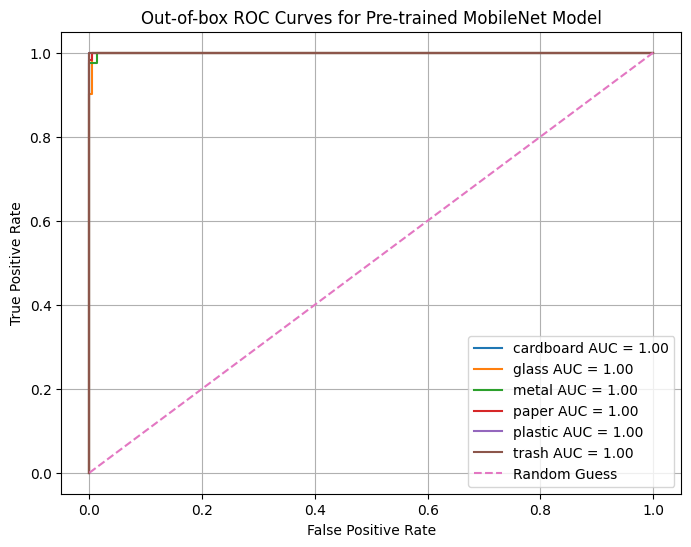

In [ ]:
# ============================================================
# 10) ROC Curves
# ============================================================

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    class_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_name} AUC = {class_auc:.2f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Out-of-box ROC Curves for Pre-trained MobileNet Model")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# 11) Test loss and test accuracy
# ============================================================

model_f.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

test_loss, test_accuracy = model_f.evaluate(test_dataset, verbose=0)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 0.055
Test Accuracy: 0.9767


<Figure size 800x600 with 0 Axes>

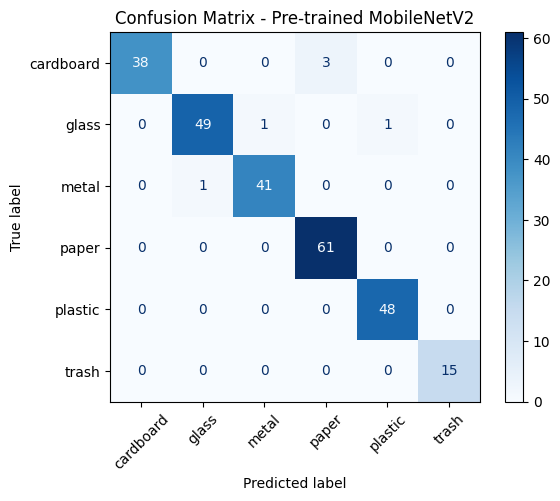

In [ ]:
# ============================================================
# 12) Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(8, 6))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Pre-trained MobileNetV2")
plt.show()